In [ ]:
from sklearn.ensemble import RandomForestClassifier  
from xgboost import XGBClassifier
import pandas as pd 
from sklearn.metrics import classification_report , accuracy_score 


In [33]:
train_data = pd.read_csv("../data/processed/train_data.csv")
test_data = pd.read_csv("../data/processed/test_data.csv")

In [34]:
X_train = train_data.drop("is_canceled", axis=1)
y_train = train_data["is_canceled"]

In [35]:
X_test = test_data.drop("is_canceled", axis=1)
y_test = test_data["is_canceled"]

In [36]:
#RandomForestClassifier model training 
rfc = RandomForestClassifier(n_estimators=200, random_state=42 )

rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
#predict X_test
y_pred_rfc = rfc.predict(X_test)

In [48]:
#evaluation 

print(f"accuracy score: {accuracy_score(y_pred_rfc,y_test)}")
print(f"classificationreport: {classification_report(y_pred_rfc,y_test)}")


accuracy score: 0.7611655669552615
classificationreport:               precision    recall  f1-score   support

           0       0.87      0.81      0.84     20462
           1       0.46      0.58      0.52      5757

    accuracy                           0.76     26219
   macro avg       0.67      0.70      0.68     26219
weighted avg       0.78      0.76      0.77     26219



plot the results 

In [39]:
import matplotlib.pyplot as plt 
import seaborn as sns 

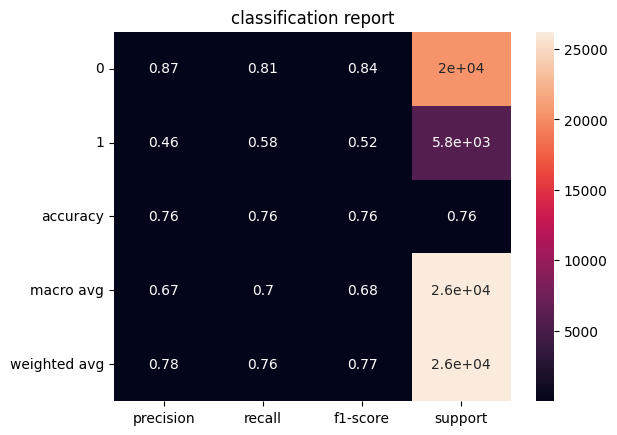

In [54]:
report_rfc = classification_report(y_pred_rfc, y_test, output_dict=True) 

d_report =pd.DataFrame(report_rfc).transpose() 

sns.heatmap(d_report, annot=True ) 
plt.title("classification report")
plt.show()

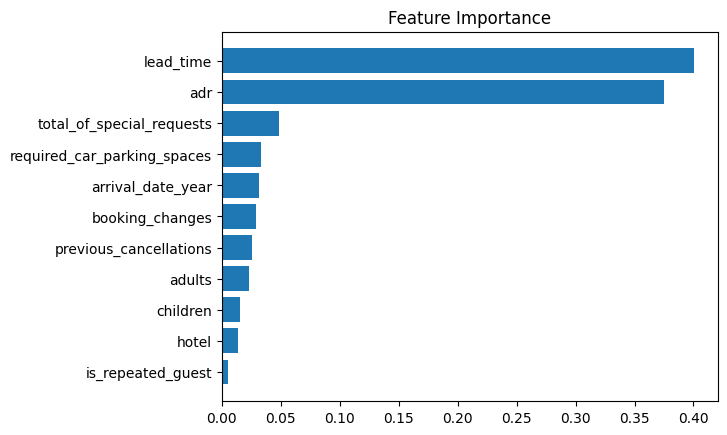

In [41]:
importance = rfc.feature_importances_ 
feature = X_train.columns 

d_fe = pd.DataFrame(
            {
                "feature" : feature,
                "importance" : importance 

            }
) 

d_fe = d_fe.sort_values("importance", ascending= True) 

plt.barh(d_fe["feature"], d_fe["importance"])
plt.title("Feature Importance")
plt.show()

In [42]:
d_fe

,feature,importance
3,is_repeated_guest,0.005441
6,hotel,0.013904
2,children,0.015467
1,adults,0.023063
8,previous_cancellations,0.025192
9,booking_changes,0.028609
0,arrival_date_year,0.031266
10,required_car_parking_spaces,0.032833
4,total_of_special_requests,0.048809
5,adr,0.374779


In [46]:
xgc = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
xgc.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [49]:
y_pred_xgc = xgc.predict(X_test)

In [53]:
#evaluation 

print(f"accuracy score: {accuracy_score(y_pred_xgc,y_test)}")
print(f"classificationreport: {classification_report(y_pred_xgc,y_test)}")


accuracy score: 0.7793203402112971
classificationreport:               precision    recall  f1-score   support

           0       0.93      0.80      0.86     22014
           1       0.39      0.67      0.49      4205

    accuracy                           0.78     26219
   macro avg       0.66      0.73      0.68     26219
weighted avg       0.84      0.78      0.80     26219



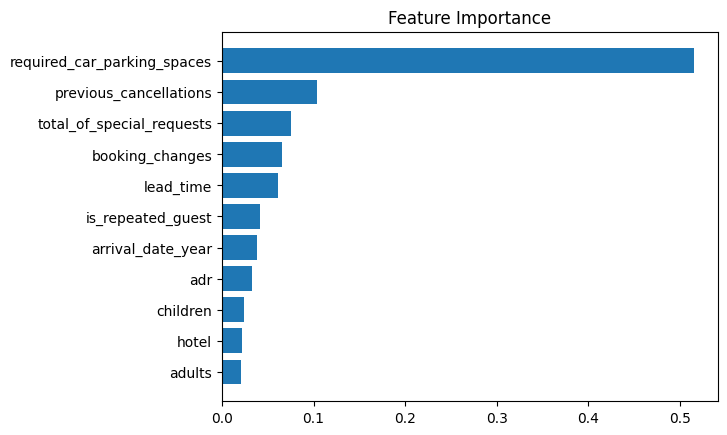

In [57]:
importance = xgc.feature_importances_ 
feature = X_train.columns 

d_xg = pd.DataFrame(
            {
                "feature" : feature,
                "importance" : importance 

            }
) 

d_xg = d_xg.sort_values("importance", ascending= True) 

plt.barh(d_xg["feature"], d_xg["importance"])
plt.title("Feature Importance")
plt.show()

In [58]:
d_xg

,feature,importance
1,adults,0.020540
6,hotel,0.021554
2,children,0.024411
5,adr,0.032481
0,arrival_date_year,0.038813
3,is_repeated_guest,0.041545
7,lead_time,0.061115
9,booking_changes,0.065746
4,total_of_special_requests,0.075048
8,previous_cancellations,0.103386
